NVIDIA STOCK ANALYSIS 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOADING THE CSV FILE AND GATHERING BASIC INFO OF THE DATASET

In [2]:
df = pd.read_csv('stocks.csv')
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume',
       'shares_outstanding_bn', 'market_cap_usd_bn',
       'quarterly_revenue_usd_bn', 'sma_20', 'sma_50', 'sma_200', 'rsi_14',
       'stock_split', 'era', 'key_event'],
      dtype='object')

In [7]:
df.shape # (number of rows, number of columns)

(7079, 19)

In [8]:
df.dtypes

date                         object
open                        float64
high                        float64
low                         float64
close                       float64
volume                        int64
shares_outstanding_bn       float64
market_cap_usd_bn           float64
quarterly_revenue_usd_bn    float64
sma_20                      float64
sma_50                      float64
sma_200                     float64
rsi_14                      float64
stock_split                 float64
era                          object
key_event                    object
price_change                float64
daily_return                float64
daily_return_pct            float64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079 entries, 0 to 7078
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      7079 non-null   object 
 1   open                      7079 non-null   float64
 2   high                      7079 non-null   float64
 3   low                       7079 non-null   float64
 4   close                     7079 non-null   float64
 5   volume                    7079 non-null   int64  
 6   shares_outstanding_bn     7079 non-null   float64
 7   market_cap_usd_bn         7079 non-null   float64
 8   quarterly_revenue_usd_bn  7079 non-null   float64
 9   sma_20                    7079 non-null   float64
 10  sma_50                    7079 non-null   float64
 11  sma_200                   7079 non-null   float64
 12  rsi_14                    7079 non-null   float64
 13  stock_split               6 non-null      float64
 14  era     

DATE CLEANING

In [4]:
df["date"] = pd.to_datetime(df['date'])

/var/folders/26/q8ygphr55ss1r66psnfwx_mc0000gn/T/ipykernel_5183/3435947568.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df['date'])


In [5]:
df["stock_split"] = df["stock_split"].fillna(0)

In [6]:
df["key_event"] = df["key_event"].fillna("No Event")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079 entries, 0 to 7078
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      7079 non-null   datetime64[ns]
 1   open                      7079 non-null   float64       
 2   high                      7079 non-null   float64       
 3   low                       7079 non-null   float64       
 4   close                     7079 non-null   float64       
 5   volume                    7079 non-null   int64         
 6   shares_outstanding_bn     7079 non-null   float64       
 7   market_cap_usd_bn         7079 non-null   float64       
 8   quarterly_revenue_usd_bn  7079 non-null   float64       
 9   sma_20                    7079 non-null   float64       
 10  sma_50                    7079 non-null   float64       
 11  sma_200                   7079 non-null   float64       
 12  rsi_14              

FEATURE ENGINEERING

In [8]:
df["price_change"] = df["close"] - df["open"]

df["daily_return"] = df["price_change"] / df["open"]

df["daily_return_pct"] = df["daily_return"] * 100

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079 entries, 0 to 7078
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      7079 non-null   datetime64[ns]
 1   open                      7079 non-null   float64       
 2   high                      7079 non-null   float64       
 3   low                       7079 non-null   float64       
 4   close                     7079 non-null   float64       
 5   volume                    7079 non-null   int64         
 6   shares_outstanding_bn     7079 non-null   float64       
 7   market_cap_usd_bn         7079 non-null   float64       
 8   quarterly_revenue_usd_bn  7079 non-null   float64       
 9   sma_20                    7079 non-null   float64       
 10  sma_50                    7079 non-null   float64       
 11  sma_200                   7079 non-null   float64       
 12  rsi_14              

In [10]:
positive_days = (df["price_change"] > 0).sum()
print(positive_days)

negative_days = (df["price_change"] < 0).sum()
print(negative_days)

total_days = len(df)
print(total_days)

    

3526
3484
7079


In [11]:
positive_pct = (positive_days / total_days) * 100
negative_pct = (negative_days / total_days) * 100

print(round(positive_pct, 2))
print(round(negative_pct, 2))


49.81
49.22


In [12]:
daily_avg = df["daily_return"].mean() *100
max_gain = df["daily_return"].max() * 100
min_loss = df["daily_return"].min() * 100


print(round(daily_avg, 4)) #use my 'Short/Scientific' display mode, no need to round to 6 decimal places
print(round(max_gain, 2))
print(round(min_loss, 2))

# #with f string 
# print(f"{daily_avg:.6f}")


0.0001
1.53
-1.58


STRONG BULLISH CONDITION:
If all are:
above
uptrend
golden_cross

WEAK CONDITIONS: 
If all are:
below
downtrend
no_signal


In [13]:
#CURRENT PRICE IS GREATER THAN THE RECENT AVERAGE = ABOVE 
df["trend_signal"] = np.where(df["close"] > df["sma_20"], "Above", "Below")
df["trend_signal"].value_counts()

trend_signal
Above    3601
Below    3478
Name: count, dtype: int64

In [14]:
# RECENT PRICES ARE ABOVE THAN THE LONG TERM TREND PRICES = UPTREND 
df["trend_strength"] = np.where(df["sma_20"] > df["sma_50"], "Uptrend", "Downtrend")
df["trend_strength"].value_counts()

trend_strength
Downtrend    3599
Uptrend      3480
Name: count, dtype: int64

In [15]:
#MEDIUM TERM TREND > LONG TERM TREND = GOLDEN CROSS 
df["signal"] = np.where(df["sma_50"] > df["sma_200"], "Golden Cross", "No signal")
df["signal"].value_counts()

signal
No signal       3592
Golden Cross    3487
Name: count, dtype: int64

In [16]:
print(df[["date", "close", "trend_strength", "trend_signal", "signal"]].tail(10))

           date    close trend_strength trend_signal        signal
7069 2026-02-26  18.3312      Downtrend        Above     No signal
7070 2026-02-27  18.4086        Uptrend        Below     No signal
7071 2026-03-02  18.3975      Downtrend        Above  Golden Cross
7072 2026-03-03  18.4394        Uptrend        Below     No signal
7073 2026-03-04  18.3207      Downtrend        Above  Golden Cross
7074 2026-03-05  18.6045      Downtrend        Above     No signal
7075 2026-03-06  18.5820      Downtrend        Above  Golden Cross
7076 2026-03-09  18.5577      Downtrend        Below  Golden Cross
7077 2026-03-10  18.5336      Downtrend        Below  Golden Cross
7078 2026-03-11  18.6000        Uptrend        Below     No signal


In [17]:
print(df["trend_signal"].value_counts())
print(df["trend_strength"].value_counts())
print(df["signal"].value_counts())

trend_signal
Above    3601
Below    3478
Name: count, dtype: int64
trend_strength
Downtrend    3599
Uptrend      3480
Name: count, dtype: int64
signal
No signal       3592
Golden Cross    3487
Name: count, dtype: int64


Strong bullish condition across all timeframes


In [18]:
condition = (
    (df["trend_signal"] == "Above") &
    (df["trend_strength"] == "Uptrend") &
    (df["signal"] == "Golden Cross")
)


In [19]:
strong_bullish = condition.sum()
print(strong_bullish)


472


In [20]:
strong_bullish_pct = (strong_bullish / len(df)) * 100
print(round(strong_bullish_pct, 2))

6.67


VOLATILITY - how much the price fluctuates over time

In [21]:
volatility = np.std(df["daily_return"].to_numpy())
volatility_pct = volatility * 100

print(f"Volatility: {volatility_pct:.3f}%")

Volatility: 0.443%


On average, NVIDIA stock fluctuates by about 0.443% per day.

In [22]:
uptrend_mask = (df["trend_strength"] == "Uptrend")
downtrend_mask = (df["trend_strength"] == "Downtrend")

#filtering the daily returns based on the trend strength
uptrend_returns = df["daily_return"][uptrend_mask]
downtrend_returns = df["daily_return"][downtrend_mask]

#calculating volatility for uptrends and downtrends
up_vol = np.std(uptrend_returns) * 100
down_vol = np.std(downtrend_returns) * 100

#displaying the volatility for uptrends and downtrends
print(f"Uptrend Volatility: {up_vol:.3f}%")
print(f"Downtrend Volatility: {down_vol:.3f}%")

Uptrend Volatility: 0.446%
Downtrend Volatility: 0.441%


## VISUALIZATION OF THE ANALYSIS 

Date wise daily returns, 0> are the negative returns, 0< are the positive returns 

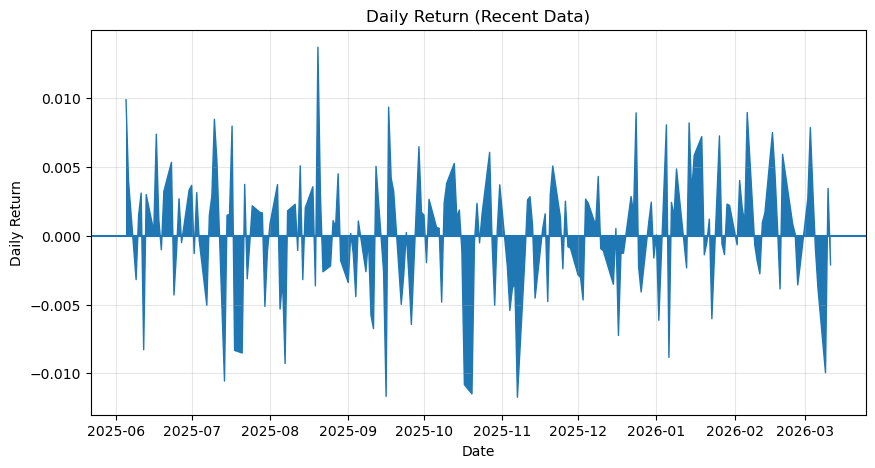

In [27]:
df_recent = df.tail(200)

plt.figure(figsize=(10,5))
plt.axhline(0)

plt.plot(df_recent["date"], df_recent["daily_return"], linewidth=1)
plt.fill_between(df_recent["date"], df_recent["daily_return"], 0)

plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Daily Return (Recent Data)")

plt.grid(True, alpha=0.3)
plt.show()

Where is the price going and how strong is the trend?

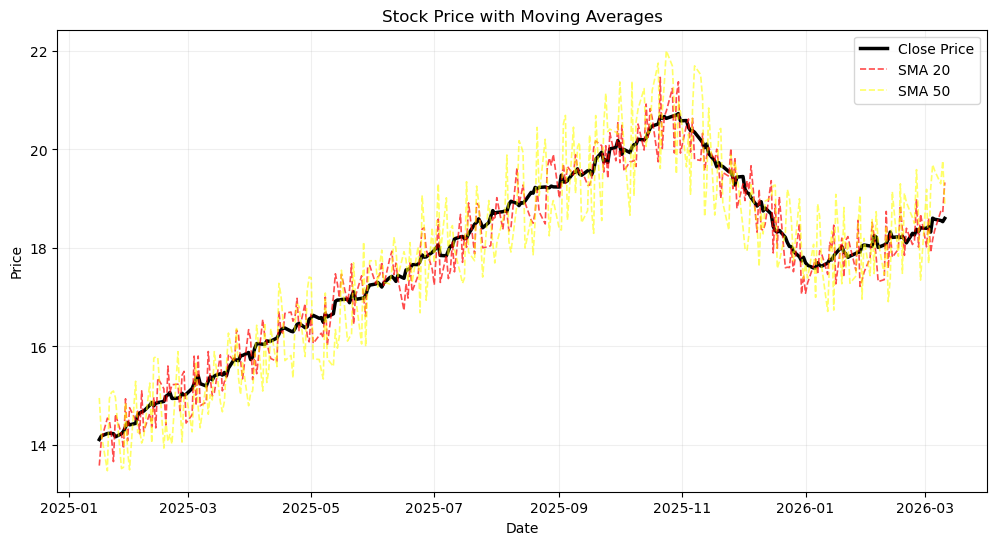

In [32]:
df_recent = df.tail(300)

plt.figure(figsize=(12,6))

# MAIN price (bold)
plt.plot(
    df_recent["date"],
    df_recent["close"],
    color="black",
    linewidth=2.5,
    label="Close Price"
)

# SMA 20 (lighter, thinner)
plt.plot(
    df_recent["date"],
    df_recent["sma_20"],
    color="red",
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    label="SMA 20"
)

# SMA 50 (even softer)
plt.plot(
    df_recent["date"],
    df_recent["sma_50"],
    color="yellow",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    label="SMA 50"
)

# Labels
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price with Moving Averages")

# Clean legend
plt.legend()

# Subtle grid
plt.grid(True, alpha=0.2)

plt.show()

How often is the market bullish vs bearish?

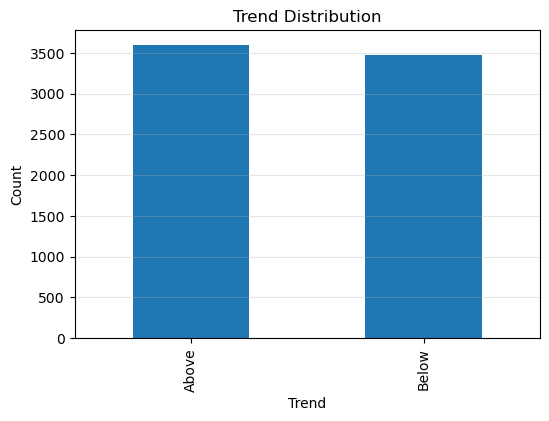

In [34]:
trend_counts = df["trend_signal"].value_counts()

plt.figure(figsize=(6,4))
trend_counts.plot(kind="bar")

plt.title("Trend Distribution")
plt.xlabel("Trend")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)
plt.show()

How are returns distributed?

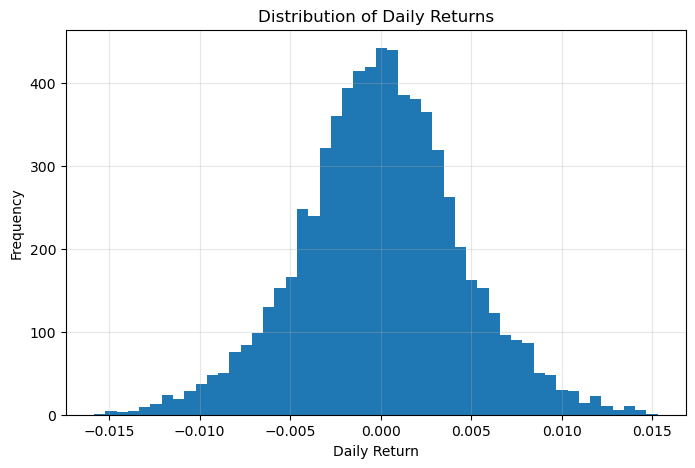

In [35]:
plt.figure(figsize=(8,5))

plt.hist(df["daily_return"], bins=50)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns")

plt.grid(True, alpha=0.3)
plt.show()